# Assignment 6: Building Your First Neural Network

**Student Name:** [Your Name Here]

**Date:** [Date]

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\aj4ho\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\tensorflow\\core\\protobuf\\fingerprint_pb2.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


                                              0.0/294.9 kB ? eta -:--:--
     ------------                            92.2/294.9 kB 1.8 MB/s eta 0:00:01
     ------------------------------------   286.7/294.9 kB 3.0 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00
                                              0.0/350.8 MB ? eta -:--:--
                                             0.6/350.8 MB 19.2 MB/s eta 0:00:19
                                             1.8/350.8 MB 23.5 MB/s eta 0:00:15
                                             3.9/350.8 MB 30.9 MB/s eta 0:00:12
                                             6.6/350.8 MB 38.4 MB/s eta 0:00:09
     -                                       9.4/350.8 MB 42.8 MB/s eta 0:00:08
     -                                      12.1/350.8 MB 65.6 MB/s eta 0:00:06
     -                                      14.0/350.8 MB 54.7 MB/s eta 0:00:07
     -                                      17.4/350.8

In [4]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop(columns=['Activity'])
y_train = train_df['Activity']
X_test = test_df.drop(columns=['Activity'])
y_test = test_df['Activity']

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [5]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [7]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(6, activation='softmax')
])
# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']

baseline_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

c:\Users\aj4ho\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [8]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled, y_test)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8903 - loss: 0.2958 - val_accuracy: 0.9300 - val_loss: 0.1865
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9723 - loss: 0.0923 - val_accuracy: 0.9375 - val_loss: 0.1733
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9804 - loss: 0.0613 - val_accuracy: 0.9361 - val_loss: 0.1766
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9844 - loss: 0.0488 - val_accuracy: 0.9388 - val_loss: 0.1807
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9874 - loss: 0.0401 - val_accuracy: 0.9381 - val_loss: 0.1911
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9891 - loss: 0.0339 - val_accuracy: 0.9368 - val_loss: 0.2025
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9912 - loss: 0.0296 - val_accuracy: 0.9388 - val_loss: 0.2164
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [9]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile with same settings as baseline
medium_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9038 - loss: 0.2540 - val_accuracy: 0.9354 - val_loss: 0.1510
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9704 - loss: 0.0826 - val_accuracy: 0.9381 - val_loss: 0.1396
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9779 - loss: 0.0624 - val_accuracy: 0.9388 - val_loss: 0.1674
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9832 - loss: 0.0429 - val_accuracy: 0.9402 - val_loss: 0.1671
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9862 - loss: 0.0377 - val_accuracy: 0.9402 - val_loss: 0.1616
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9456 - val_loss: 0.1581
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9449 - val_loss: 0.1750
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accur

### Deep Network (3 Layers)

In [10]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')


deep_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile with same settings
deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test_scaled, y_test)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8874 - loss: 0.2981 - val_accuracy: 0.9375 - val_loss: 0.1430
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9677 - loss: 0.0933 - val_accuracy: 0.9402 - val_loss: 0.1411
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9762 - loss: 0.0656 - val_accuracy: 0.9368 - val_loss: 0.1617
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9762 - loss: 0.0617 - val_accuracy: 0.9334 - val_loss: 0.1605
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9806 - loss: 0.0453 - val_accuracy: 0.9443 - val_loss: 0.1466
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9886 - loss: 0.0316 - val_accuracy: 0.9354 - val_loss: 0.1813
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9912 - loss: 0.0242 - val_accuracy: 0.9347 - val_loss: 0.2148
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accurac

### Compare Depth Experiments

In [11]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.930777
    2 Layers (128, 64)       0.930777
3 Layers (128, 64, 32)       0.939260


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

Adding more layers slightly improved the model’s performance, but the improvement was small. The accuracy stayed the same from one layer to two layers (0.9308) and only increased slightly when a third layer was added (0.9393). This suggests diminishing returns after a certain depth, where adding more layers does not significantly improve accuracy and may add unnecessary complexity.

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [12]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
narrow_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(X_test_scaled, y_test)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20


c:\Users\aj4ho\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8400 - loss: 0.4286 - val_accuracy: 0.9341 - val_loss: 0.1883
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9599 - loss: 0.1161 - val_accuracy: 0.9347 - val_loss: 0.1713
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9765 - loss: 0.0736 - val_accuracy: 0.9381 - val_loss: 0.1722
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9813 - loss: 0.0554 - val_accuracy: 0.9361 - val_loss: 0.1912
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9847 - loss: 0.0455 - val_accuracy: 0.9361 - val_loss: 0.2052
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9872 - loss: 0.0389 - val_accuracy: 0.9327 - val_loss: 0.2147
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9893 - loss: 0.0347 - val_accuracy: 0.9341 - val_loss: 0.2244
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9903 - loss: 0.0319 - val_accuracy: 0.9341 - val_

### Medium Width Network (2 Layers, 64 Nodes Each)

In [15]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
medium_width_model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8755 - loss: 0.3375 - val_accuracy: 0.9259 - val_loss: 0.1692
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9714 - loss: 0.0847 - val_accuracy: 0.9307 - val_loss: 0.1607
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9774 - loss: 0.0597 - val_accuracy: 0.9368 - val_loss: 0.1528
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9813 - loss: 0.0460 - val_accuracy: 0.9388 - val_loss: 0.1553
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9855 - loss: 0.0355 - val_accuracy: 0.9381 - val_loss: 0.1627
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9886 - loss: 0.0303 - val_accuracy: 0.9402 - val_loss: 0.1798
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9917 - loss: 0.0260 - val_accuracy: 0.9368 - val_loss: 0.2136
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5m

### Wide Network (2 Layers, 128 Nodes Each)

In [16]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])


# TODO: Compile  with the same settings
wide_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])


# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test_scaled, y_test)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8975 - loss: 0.2610 - val_accuracy: 0.9327 - val_loss: 0.1588
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9699 - loss: 0.0798 - val_accuracy: 0.9415 - val_loss: 0.1460
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9770 - loss: 0.0625 - val_accuracy: 0.9409 - val_loss: 0.1515
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9835 - loss: 0.0434 - val_accuracy: 0.9368 - val_loss: 0.1766
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9883 - loss: 0.0324 - val_accuracy: 0.9368 - val_loss: 0.1843
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9893 - loss: 0.0299 - val_accuracy: 0.9395 - val_loss: 0.2113
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9799 - loss: 0.0611 - val_accuracy: 0.9415 - val_loss: 0.2104
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

### Compare Width Experiments

In [17]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.925348
 2 Layers (64 each)       0.921276
2 Layers (128 each)       0.936546


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

Increasing the number of nodes per layer generally improves the model’s ability to learn more complex patterns, which can lead to higher accuracy. However, after a certain point, adding more nodes provides only small improvements while increasing the model’s complexity and training time. This shows diminishing returns, where wider layers may not significantly boost performance compared to the extra computational cost.

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [18]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model =  medium_width_model  # Replace with your best architecture

# TODO: Compile the model
best_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])


print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(X_train_scaled, y_train, epochs=30, validation_split=0.2)

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test_scaled, y_test)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Describe your architecture here]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...
Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0107 - val_accuracy: 0.9082 - val_loss: 0.5280
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9920 - loss: 0.0245 - val_accuracy: 0.9409 - val_loss: 0.3500
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9937 - loss: 0.0164 - val_accuracy: 0.9354 - val_loss: 0.3241
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9939 - loss: 0.0167 - val_accuracy: 0.9402 - val_loss: 0.3329
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9971 - loss: 0.0071 - val_accuracy: 0.9286 - val_loss: 0.4841
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9980 - loss: 0.0054 - val_accuracy: 0.9334 - val_loss: 0.4583
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9963 - loss: 0.0086 - val_accuracy: 0.9388 - val_loss: 0.3250
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9

### Visualize Training Progress - Accuracy

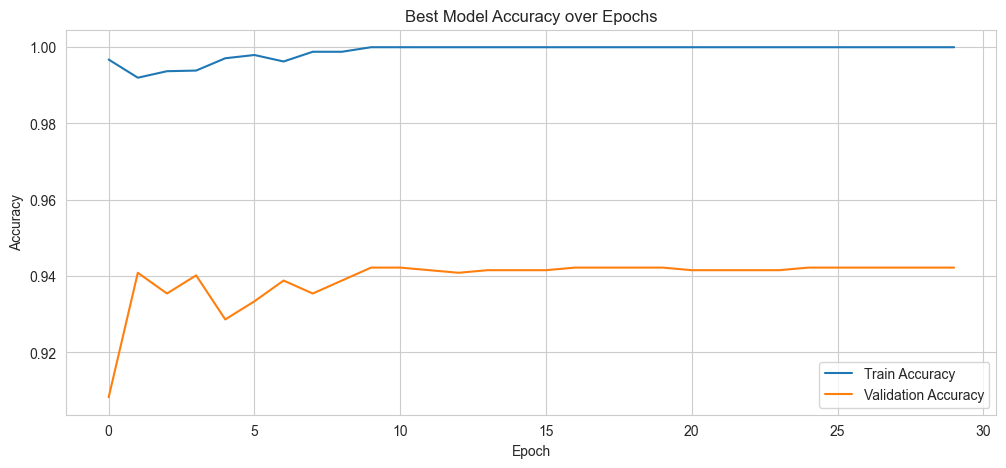

In [19]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(best_history.history['accuracy'], label='Train Accuracy')
    plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Best Model Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()    
    
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

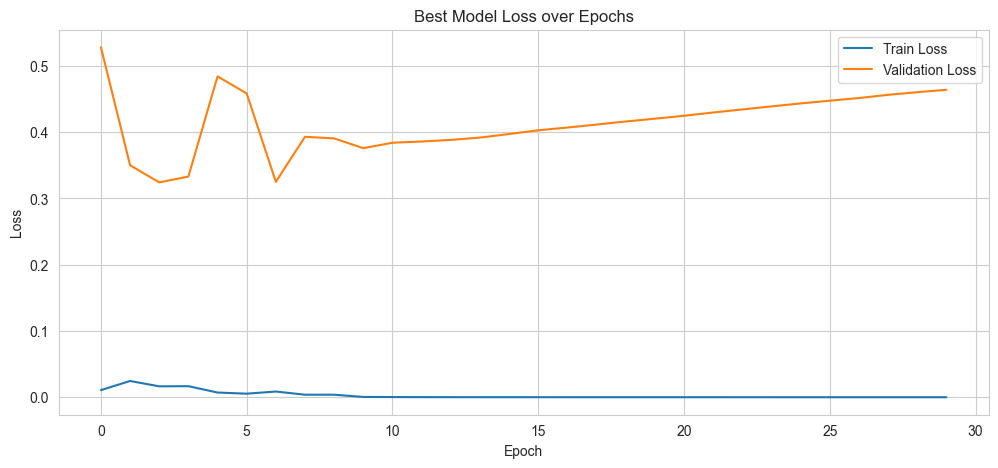

In [20]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(best_history.history['loss'], label='Train Loss')
    plt.plot(best_history.history['val_loss'], label='Validation Loss')
    plt.title('Best Model Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()    
    
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [21]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.863590
unit7_pca_rf_time = 5.080161

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (Your Architecture)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '[Describe your architecture]',
        '26 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)



MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model              Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)               1 hidden layer       0.930777        26.28s
    Best NN (Your Architecture) [Describe your architecture]       0.929080        38.91s
    Unit 7: PCA + Random Forest            26 PCA components       0.863590         5.08s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

Neural networks performed better than the PCA + Random Forest model in this experiment. The baseline neural network achieved about 93.1% accuracy and the best neural network achieved 92.9%, both outperforming the 86.4% accuracy from the PCA + Random Forest model. This suggests that the neural network’s ability to automatically learn patterns from the raw sensor data was more effective than manually reducing features with PCA, although the PCA + Random Forest model trained faster and is generally easier to interpret.

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

Neural networks are best suited for complex data types such as images, text, audio, or high-dimensional sensor data where patterns are difficult to engineer manually. They are most useful when large datasets are available and maximizing predictive performance is more important than interpretability. For example, a neural network would be a good choice for recognizing objects in images or analyzing wearable sensor data for activity detection. Simpler models like random forests are often better for structured tabular data, especially in business or analytics settings where models need to train quickly and be easier to interpret, such as predicting customer churn or housing prices.

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.